## **CIFAR-10 Neural Network Evaluation Notebook**

This Jupyter notebook is designed to help verify and understand both the **data pipeline** and the **model behavior** used for the CIFAR-10 classification task. It focuses on two key components:

### **1. Evaluating the `CifarDataModule`**

* The raw CIFAR-10 images are **unnormalized** to restore their original appearance.
* images from a random picked batche are visualized to confirm that:
  * data loading works correctly,
  * normalization and augmentation steps are applied as expected,
  * class labels match the image content.
* This step helps ensure the dataset is prepared properly before feeding it into the neural network.

### **2. Reviewing Model Performance**

* The trained neural network is used to generate predictions on the **training**, **validation**, and **test** datasets.
* For each dataset:
  * images are shown together with their **predicted labels** and compared with their **true labels**,
  * incorrect predictions are highlighted to better understand failure patterns.
* These visualizations supplement numerical evaluation metrics and provide an intuitive understanding of how the model behaves on real samples.

Together, these steps give a clear overview of both the **data quality** and the **model’s predictive performance**, allowing deeper insights into its strengths, limitations, and potential areas for improvement.



In [1]:
from CifarDataModule import CifarDataModule
from CifarNNMdl import CifarNNML

from torch.utils.data import DataLoader
import lightning as L

import matplotlib.pyplot as plt
import torch
import numpy as np
import random

Seed set to 42


In [2]:
# Cifar-10 class names
classes = ['plane', 'car', 'bird', 'cat', 'deer', 
           'dog', 'frog', 'horse', 'ship', 'truck']

### Evaluating the CifarDataModule

CPU times: user 387 μs, sys: 1.23 ms, total: 1.62 ms
Wall time: 2.5 ms
Files already downloaded and verified
Files already downloaded and verified
CPU times: user 31.7 s, sys: 10.4 s, total: 42.1 s
Wall time: 44.1 s
CPU times: user 263 μs, sys: 1.48 ms, total: 1.74 ms
Wall time: 4.16 ms


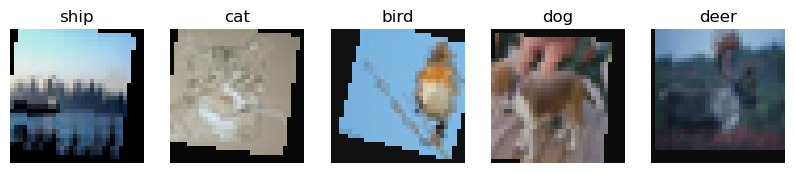

In [6]:
# instance DataModule
%time cifar_data = CifarDataModule()
# set datasets
%time cifar_data.setup()

# get train_dataloader
%time train_loader = cifar_data.train_dataloader()

# get a random batch
images, labels = next(iter(train_loader))  

# pick 5 random indices from the batch
indices = random.sample(range(images.size(0)), 5)

# plot the image with label
plt.figure(figsize=(10, 5))
for i, idx in enumerate(indices):
    img = images[idx].permute(1, 2, 0)  # C,H,W -> H,W,C
    img = img * torch.tensor([0.2470, 0.2435, 0.2616]) + torch.tensor([0.4914, 0.4822, 0.4465])  # unnormalize
    img = torch.clamp(img, 0, 1)
    
    plt.subplot(1, 5, i+1)
    plt.imshow(img.numpy())
    plt.title(classes[labels[idx].item()])
    plt.axis('off')

plt.show()

### Check Model Performance

In [3]:
def random_batch_pick(dataloader):
    batch_idx = np.random.randint(len(dataloader))
    for i, batch in enumerate(dataloader):
        if i == batch_idx:
            return (i, batch)
            break

def plot_util(dataloader, results_list):
    plt.figure(figsize=(15, 15))
    for row in range(10):
        # random pick a batch from the dataloader
        batch_idx, batch = random_batch_pick(dataloader)
        y_hat = results_list[batch_idx]
        x, y = batch
        # random pick 10 images 
        imag_idx = random.sample(range(x.size(0)), 10)
        
        for column in range(len(imag_idx)):
            idx = imag_idx[column]
            # reshape the data from chanel height width to height width channel
            img = x[idx].permute(1, 2, 0)  # C,H,W -> H,W,C
            # unnormalize
            img = img * torch.tensor([0.2470, 0.2435, 0.2616]) + torch.tensor([0.4914, 0.4822, 0.4465]) 
            img = torch.clamp(img, 0, 1)
        
            ax = plt.subplot(10, 10, row * 10 + column + 1)
            ax.imshow(img.numpy())

            ax.set_xticks([])
            ax.set_yticks([])
            
            pred_label = classes[y_hat['pred'][idx]]
            true_label = classes[y[idx].item()]
            frame_color = "red" if pred_label != true_label else "green"            
            ax.set_title(f"{pred_label}_{true_label}")
            for spine in ax.spines.values():
                spine.set_edgecolor(frame_color)
                spine.set_linewidth(3)
    
    plt.show()

def cal_accuracy(dataloader, results_list):
    true_false = []
    for idx, batch in enumerate(dataloader):
        _, y = batch
        y_hat = results_list[idx]['pred']
        true_false.extend(y == y_hat)
    return 1 - true_false.count(False) / len(true_false)      
    


In [4]:
# instance the my own cnn model, initializing with best accuracy checkpoints 
cifar_myown__nn = CifarNNML.load_from_checkpoint("./checkpoints_myown_epoch200/cifar-epoch=192-val_acc=0.89.ckpt", model_type = 'myown')

cifar_resnet18 = CifarNNML.load_from_checkpoint("./checkpoints_resnet18/cifar-epoch=129-val_acc=0.9272.ckpt", model_type = 'ResNet18')

# creat a trainer
cifar_trainer = L.Trainer(enable_progress_bar = True)




💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


In [7]:
# get train datasets run prediction
train_loader = DataLoader(cifar_data._train_dataset, batch_size=32, shuffle=False)
pred_train_data_myown_nn = cifar_trainer.predict(cifar_myown__nn, dataloaders = train_loader)
pred_train_data_resnet = cifar_trainer.predict(cifar_resnet18, dataloaders = train_loader)
print(f'\n\n\nThe accuracy of the train dataset, my own mdel : resnet18,\n\n {cal_accuracy(train_loader, pred_train_data_myown_nn)} : {cal_accuracy(train_loader, pred_train_data_resnet)}\n\n\n')
#plot_util(train_loader, pred_train_data_myown_nn)

/Users/botang/Documents/Conda3/envs/MyCondaEnv/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


Predicting DataLoader 0: 100%|██████████| 1485/1485 [00:51<00:00, 28.70it/s]



The accuracy of the train dataset, my own mdel : resnet18 0.9054736842105263 : 0.9842105263157894





In [8]:
val_loader = DataLoader(cifar_data._val_dataset, batch_size=32, shuffle=False)
pred_val_data_myown_nn = cifar_trainer.predict(cifar_myown__nn, dataloaders = val_loader)
pred_val_data_resnet = cifar_trainer.predict(cifar_resnet18, dataloaders = val_loader)
print(f'\n\n\nThe accuracy of the eva dataset, my own mdel : resnet18,\n\n {cal_accuracy(val_loader, pred_val_data_myown_nn)} : {cal_accuracy(val_loader, pred_val_data_resnet)}\n\n\n')
#plot_util(val_loader, pred_val_data_myown_nn)

Predicting DataLoader 0: 100%|██████████| 79/79 [00:02<00:00, 32.23it/s]



The accuracy of the eva dataset, my own mdel : resnet18,

 0.8868 : 0.9272





In [9]:
test_loader = DataLoader(cifar_data._test_dataset, batch_size=32, shuffle=False)
pred_test_data_myown_nn = cifar_trainer.predict(cifar_myown__nn, dataloaders = test_loader)
pred_test_data_resnet = cifar_trainer.predict(cifar_resnet18, dataloaders = test_loader)
print(f'\n\n\nThe accuracy of the test dataset, my own mdel : resnet18,\n\n {cal_accuracy(test_loader, pred_test_data_myown_nn)} : {cal_accuracy(test_loader, pred_test_data_resnet)}\n\n\n')


Predicting DataLoader 0: 100%|██████████| 313/313 [00:09<00:00, 32.79it/s]



The accuracy of the test dataset, my own mdel : resnet18,

 0.8793 : 0.919





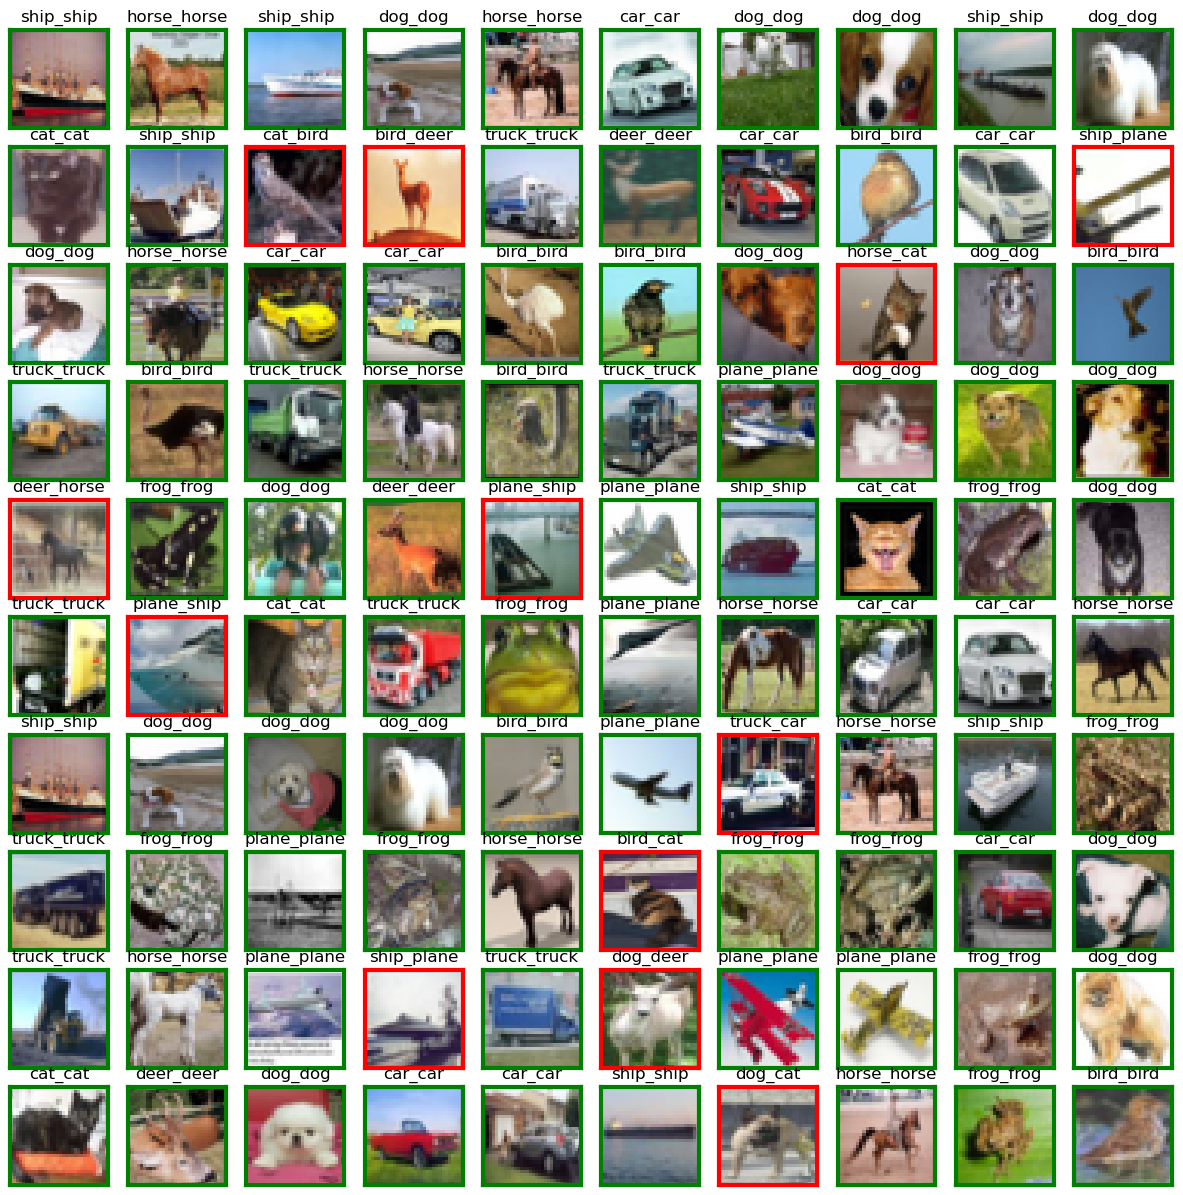

In [10]:
plot_util(test_loader, pred_test_data_myown_nn)

## Accuracy Comparison between my own CNN model and Resnet18

### Datasetup
- Cifar10 Trainset is spliited randomly to train and eval dataset, for reproduce reason, same random seed is used
- Cifar10 Testset is used for test

### Accuracy Results

| Model Type | Accuracy of Train Dataset | Accuracy of Eval Dataset | Accuracy of Test Dataset 
|:-----------|:-----------------|:---------------|:---------------
| My own CNN model | 0.905    | 0.887         |0.879
| Resnet18         | 0.984    | 0.9272        |0.919

### Analysis
On the one side the resnet18 has 3% higher accuracy than my own CNN mdoel. On the other the architecture of the Resnet18 is much complicated than my model with just 4 CNN layers in total plus residual connection and batch normlization. It shows the accuracy improvements are not linear. It becomes harder for last percentage points of improvement

## Conclusion

Through this project, I implemented and trained a custom CNN and compared it against a ResNet-18 on CIFAR-10 to study overfitting, regularization, and architectural inductive bias. I learned how residual connections improve optimization stability and convergence without automatically eliminating overfitting. I applied early stopping, data augmentation, and learning-rate scheduling to achieve realistic generalization performance (~89% validation accuracy). This work helped me understand the gap between training accuracy and true generalization in practical deep learning systems.